# Eddy Diffusivity on Pbar Surfaces

New notebook for estimating eddy diffusivity using the profiles with pbar as vertical coordinate

## Housekeeping

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
import matplotlib.colors as colors
import pandas as pd
import numpy as np
from importlib import reload
import cartopy.crs as ccrs
import cmocean.cm as cmo
import gsw
import scipy.ndimage as filter
import scipy.interpolate as interpolate
from flox.xarray import xarray_reduce
from xgcm.autogenerate import generate_grid_ds
from xgcm import Grid
from tqdm.notebook import tqdm
from scipy.ndimage import uniform_filter1d

In [2]:
import os
os.chdir('/home/amf2288/argo-intern/funcs')
import filt_funcs as ff
import density_funcs as df

In [3]:
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize']  = 18
plt.rcParams['axes.labelsize']  = 14
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14

In [33]:
ds_pbar_grad = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grad_bin.nc')
ds_pbar_grid = xr.open_dataset('/swot/SUM05/amf2288/ds_pbar_grid_var.nc')

In [34]:
ds_pbar_grid

<xarray.Dataset> Size: 1GB
Dimensions:          (PRESSURE_mean: 1001, LON: 120, LAT: 60, LON_left: 120,
                      LAT_left: 60)
Coordinates:
  * PRESSURE_mean    (PRESSURE_mean) int64 8kB 0 2 4 6 8 ... 1994 1996 1998 2000
  * LON              (LON) float64 960B -178.5 -175.5 -172.5 ... 175.5 178.5
  * LAT              (LAT) float64 480B -88.5 -85.5 -82.5 ... 82.5 85.5 88.5
  * LON_left         (LON_left) float64 960B -180.0 -177.0 ... 174.0 177.0
  * LAT_left         (LAT_left) float64 480B -90.0 -87.0 -84.0 ... 84.0 87.0
Data variables: (12/25)
    CT_sort          (PRESSURE_mean, LON, LAT) float64 58MB ...
    SA_sort          (PRESSURE_mean, LON, LAT) float64 58MB ...
    SPICE_sort       (PRESSURE_mean, LON, LAT) float64 58MB ...
    DENSITY          (PRESSURE_mean, LON, LAT) float64 58MB ...
    CT_sort_m        (PRESSURE_mean, LON, LAT) float64 58MB ...
    SA_sort_m        (PRESSURE_mean, LON, LAT) float64 58MB ...
    ...               ...
    CT_m_VPR         (PRESSURE_mean, LON, LAT) float64 58MB ...
    SA_m_VPR         (PRESSURE_mean, LON, LAT) float64 58MB ...
    SPICE_m_VPR      (PRESSURE_mean, LON, LAT) float64 58MB ...
    CT_meso_frac     (PRESSURE_mean, LON, LAT) float64 58MB ...
    SA_meso_frac     (PRESSURE_mean, LON, LAT) float64 58MB ...
    SPICE_meso_frac  (PRESSURE_mean, LON, LAT) float64 58MB ...

In [35]:
ds_pbar_grad

<xarray.Dataset> Size: 750MB
Dimensions:        (LON: 120, LAT: 60, PRESSURE_mean: 1001, LON_left: 120,
                    LAT_left: 60)
Coordinates:
  * LON            (LON) float64 960B -178.5 -175.5 -172.5 ... 172.5 175.5 178.5
  * LAT            (LAT) float64 480B -88.5 -85.5 -82.5 -79.5 ... 82.5 85.5 88.5
  * PRESSURE_mean  (PRESSURE_mean) int64 8kB 0 2 4 6 8 ... 1994 1996 1998 2000
  * LON_left       (LON_left) float64 960B -180.0 -177.0 -174.0 ... 174.0 177.0
  * LAT_left       (LAT_left) float64 480B -90.0 -87.0 -84.0 ... 81.0 84.0 87.0
Data variables: (12/14)
    CT_m_bin       (PRESSURE_mean, LON, LAT) float64 58MB ...
    SA_m_bin       (PRESSURE_mean, LON, LAT) float64 58MB ...
    SPICE_m_bin    (PRESSURE_mean, LON, LAT) float64 58MB ...
    DENSITY        (PRESSURE_mean, LON, LAT) float64 58MB ...
    dCT_m_dx       (PRESSURE_mean, LON, LAT) float64 58MB ...
    dCT_m_dy       (PRESSURE_mean, LON, LAT) float64 58MB ...
    ...             ...
    dSPICE_m_dx    (PRESSURE_mean, LON, LAT) float64 58MB ...
    dSPICE_m_dy    (PRESSURE_mean, LON, LAT) float64 58MB ...
    basin          (LAT, LON) float64 58kB ...
    dCT_m_dp       (PRESSURE_mean, LON, LAT) float64 58MB ...
    dSA_m_dp       (PRESSURE_mean, LON, LAT) float64 58MB ...
    dSPICE_m_dp    (PRESSURE_mean, LON, LAT) float64 58MB ...

In [36]:
K_rho_p = xr.open_dataarray('/swot/SUM05/amf2288/K_rho_filt_p.nc').drop_vars('Z').rename({'PRESSURE':'PRESSURE_mean'})
K_rho_p = K_rho_p.bfill(dim='PRESSURE_mean').ffill(dim='PRESSURE_mean')

## Calculate Diffusivity

In [37]:
ds_pbar_grad['K_e_CT'] = K_rho_p * ds_pbar_grid.CT_e_var/(ds_pbar_grad.dCT_m_dx**2 + ds_pbar_grad.dCT_m_dy**2)
ds_pbar_grad['K_e_SA'] = K_rho_p * ds_pbar_grid.SA_e_var/(ds_pbar_grad.dSA_m_dx**2 + ds_pbar_grad.dSA_m_dy**2)
ds_pbar_grad['K_e_SPICE'] = K_rho_p * ds_pbar_grid.SPICE_e_var/(ds_pbar_grad.dSPICE_m_dx**2 + ds_pbar_grad.dSPICE_m_dy**2)

In [38]:
ds_pbar_grad.to_netcdf('/swot/SUM05/amf2288/ds_pbar_grad_diff.nc')

## Evaluate Diff

In [180]:
C0 = float((ds_pbar_grad.dCT_m_dx**2 + ds_pbar_grad.dCT_m_dy**2).quantile(0.48))
C1 = float((ds_pbar_grad.dCT_m_dx**2 + ds_pbar_grad.dCT_m_dy**2).quantile(0.3))

In [182]:
lat_grad_clip = lat_grad.clip(min=C0)
K_e_CT_clip = K_rho_p * ds_pbar_grid.CT_e_var * (1/lat_grad_clip)

In [183]:
lat_grad = (ds_pbar_grad.dCT_m_dx**2 + ds_pbar_grad.dCT_m_dy**2)
lat_grad_tap = lat_grad / (lat_grad + C1)**2
K_e_CT_tap = K_rho_p * ds_pbar_grid.CT_e_var * lat_grad_tap

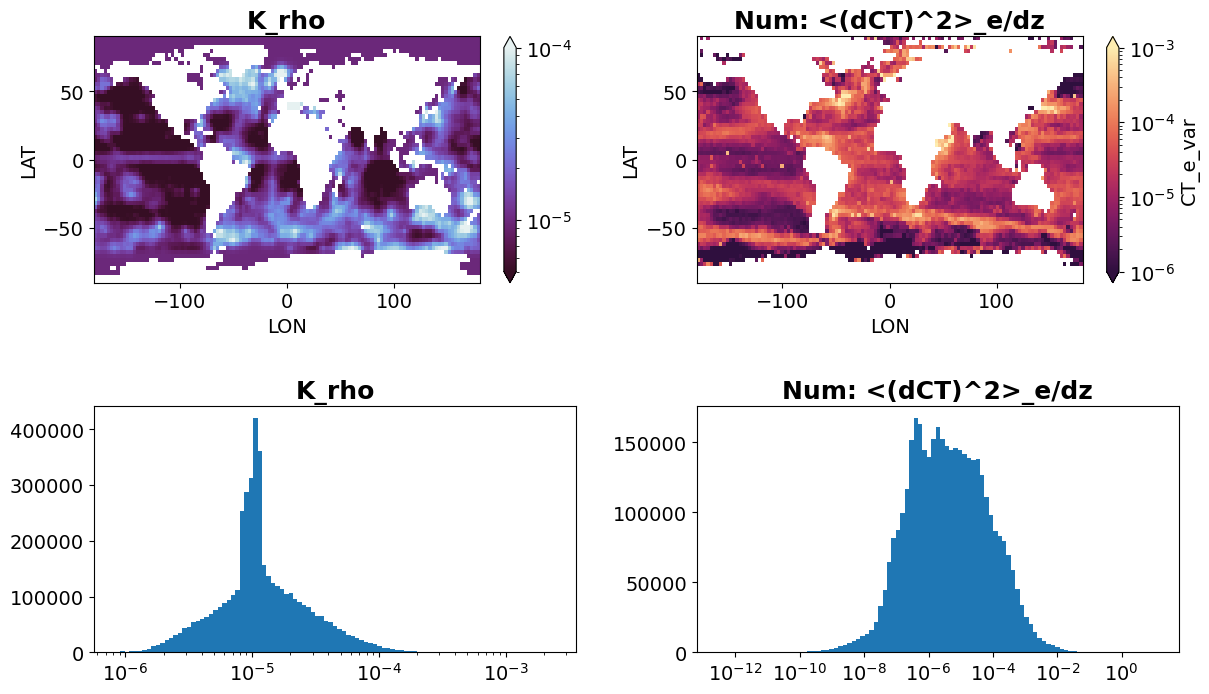

In [184]:
plt.figure(figsize=(14,8))
depth = 500

plt.subplot(221)
K_rho_p.sel(PRESSURE_mean=depth, method='nearest').plot(x='LON', y='LAT', cmap=cmo.dense_r, norm=colors.LogNorm(5e-6, 1e-4))
plt.title('K_rho')

plt.subplot(222)
ds_pbar_grid.CT_e_var.sel(PRESSURE_mean=depth, method='nearest').plot(x='LON',y='LAT', cmap=cmo.matter_r, norm=colors.LogNorm(1e-6,1e-3))
plt.title('Num: <(dCT)^2>_e/dz')

plt.subplot(223)
val = K_rho_p
plt.hist(val.values.flatten(), bins=np.logspace(np.log10(val.min()), np.log10(val.max()), 100))
plt.xscale("log")
plt.title('K_rho')

plt.subplot(224)
val = ds_pbar_grid.CT_e_var
plt.hist(val.values.flatten(), bins=np.logspace(np.log10(val.min()), np.log10(val.max()), 100))
plt.xscale("log")
plt.title('Num: <(dCT)^2>_e/dz')

plt.subplots_adjust(wspace=0.25, hspace=0.5)

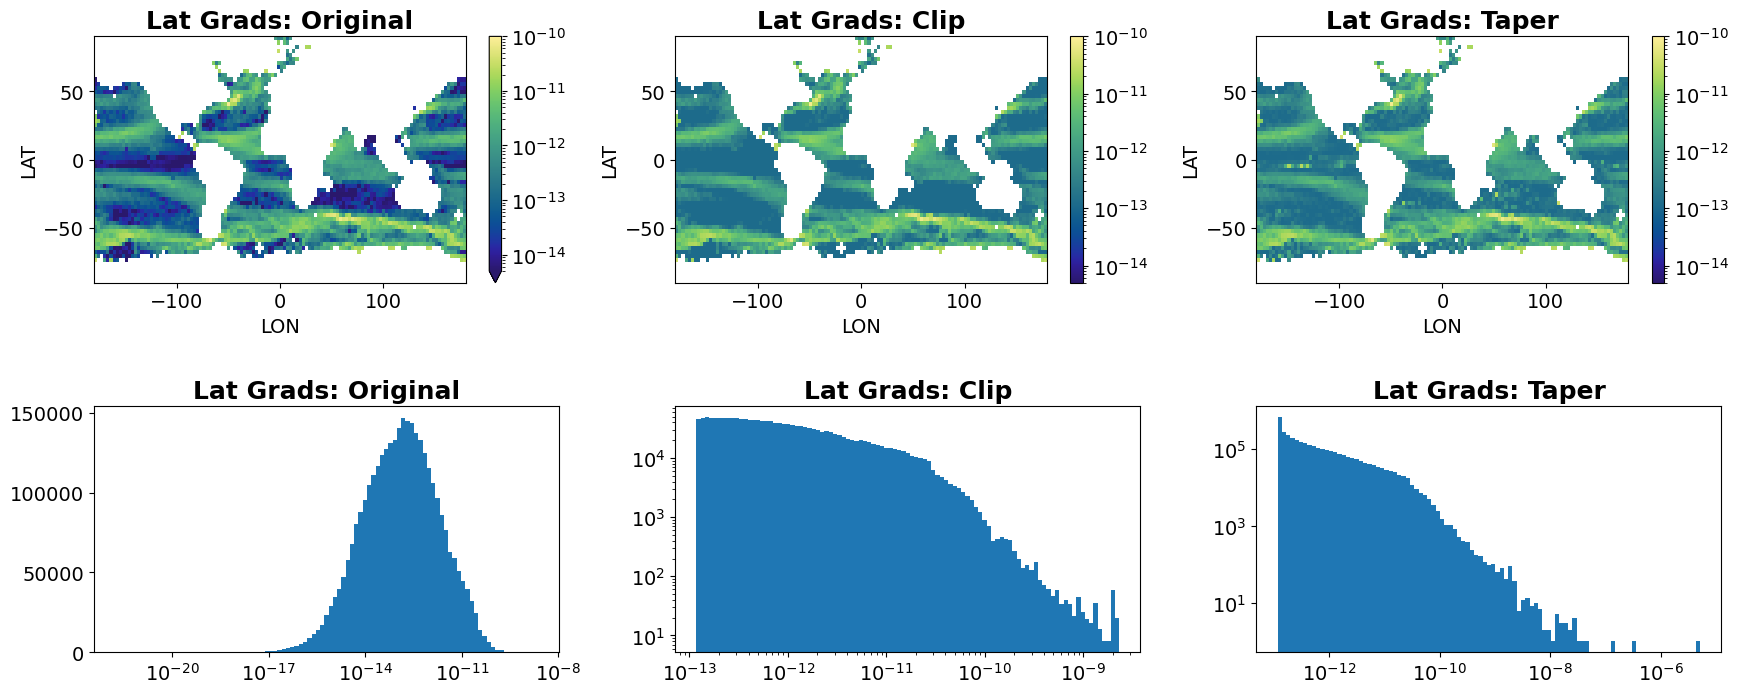

In [185]:
plt.figure(figsize=(21,8))

plt.subplot(231)
(ds_pbar_grad.dCT_m_dx**2 + ds_pbar_grad.dCT_m_dy**2).sel(PRESSURE_mean=depth, method='nearest').plot(x='LON', y='LAT', cmap=cmo.haline, norm=colors.LogNorm(5e-15, 1e-10))
plt.title('Lat Grads: Original')

plt.subplot(232)
lat_grad_clip.sel(PRESSURE_mean=depth, method='nearest').plot(x='LON', y='LAT', cmap=cmo.haline, norm=colors.LogNorm(5e-15, 1e-10))
plt.title('Lat Grads: Clip')

plt.subplot(233)
(1/lat_grad_tap).sel(PRESSURE_mean=depth, method='nearest').plot(x='LON', y='LAT', cmap=cmo.haline, norm=colors.LogNorm(5e-15, 1e-10))
plt.title('Lat Grads: Taper')

plt.subplot(234)
val = (ds_pbar_grad.dCT_m_dx**2 + ds_pbar_grad.dCT_m_dy**2)
plt.hist(val.values.flatten(), bins=np.logspace(np.log10(val.min()), np.log10(val.max()), 100))
plt.xscale("log")
plt.title('Lat Grads: Original')

plt.subplot(235)
val = lat_grad_clip
plt.hist(val.values.flatten(), bins=np.logspace(np.log10(val.min()), np.log10(val.max()), 100))
plt.xscale("log")
plt.yscale("log")
plt.title('Lat Grads: Clip')

plt.subplot(236)
val = (1/lat_grad_tap)
plt.hist(val.values.flatten(), bins=np.logspace(np.log10(val.min()), np.log10(val.max()), 100))
plt.xscale("log")
plt.yscale("log")
plt.title('Lat Grads: Taper')

plt.subplots_adjust(wspace=0.25, hspace=0.5)

Text(0.5, 1.0, 'Lat Grads')

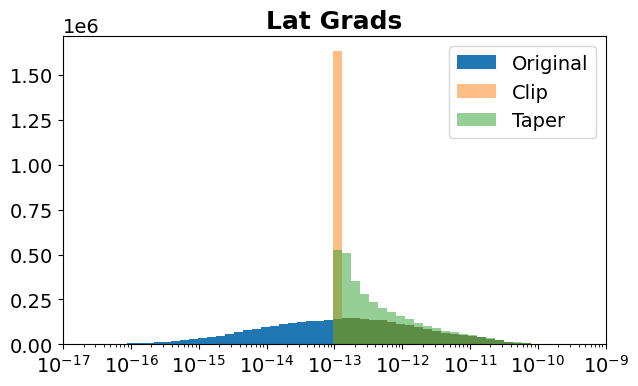

In [186]:
plt.figure(figsize=(7,4))

val = (ds_pbar_grad.dCT_m_dx**2 + ds_pbar_grad.dCT_m_dy**2)
bins = np.logspace(np.log10(val.min()), np.log10(val.max()), 100)
plt.hist(val.values.flatten(), bins=bins, label='Original')
val = lat_grad_clip
plt.hist(val.values.flatten(), bins=bins, label='Clip', alpha=0.5)
val = (1/lat_grad_tap)
plt.hist(val.values.flatten(), bins=bins, label='Taper', alpha=0.5)
plt.legend()
plt.xscale("log")
plt.xlim(1e-17,1e-9)
plt.title('Lat Grads')

Text(0.5, 1.0, 'K_e Tapered')

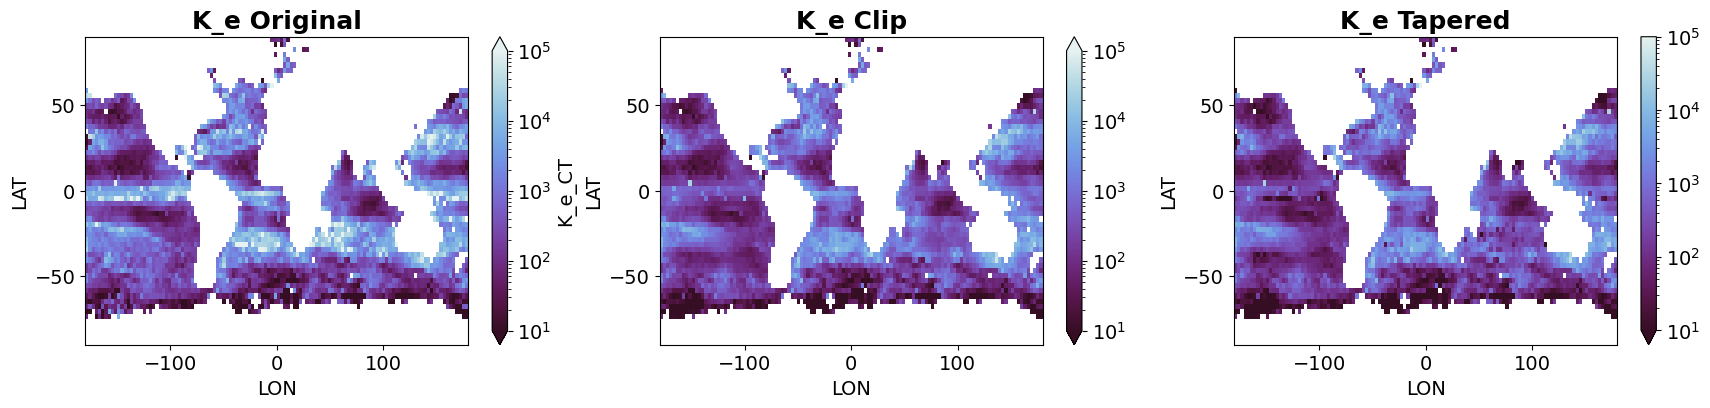

In [187]:
plt.figure(figsize=(21,4))
depth = 500


plt.subplot(131)
ds_pbar_grad.K_e_CT.sel(PRESSURE_mean=depth).plot(x='LON',y='LAT',cmap=cmo.dense_r, norm=colors.LogNorm(1e1,1e5))
plt.title('K_e Original')

plt.subplot(132)
K_e_CT_clip.sel(PRESSURE_mean=depth).plot(x='LON',y='LAT',cmap=cmo.dense_r, norm=colors.LogNorm(1e1,1e5))
plt.title('K_e Clip')

plt.subplot(133)
K_e_CT_tap.sel(PRESSURE_mean=depth).plot(x='LON',y='LAT',cmap=cmo.dense_r, norm=colors.LogNorm(1e1,1e5))
plt.title('K_e Tapered')

In [188]:
F_CT_x = -ds_pbar_grad.K_e_CT * ds_pbar_grad.dCT_m_dx
F_CT_y = -ds_pbar_grad.K_e_CT * ds_pbar_grad.dCT_m_dy

F_CT_x_clip = - K_e_CT_clip * ds_pbar_grad.dCT_m_dx
F_CT_x_tap = - K_e_CT_tap * ds_pbar_grad.dCT_m_dx

F_CT_y_clip = - K_e_CT_clip * ds_pbar_grad.dCT_m_dy
F_CT_y_tap = - K_e_CT_tap * ds_pbar_grad.dCT_m_dy

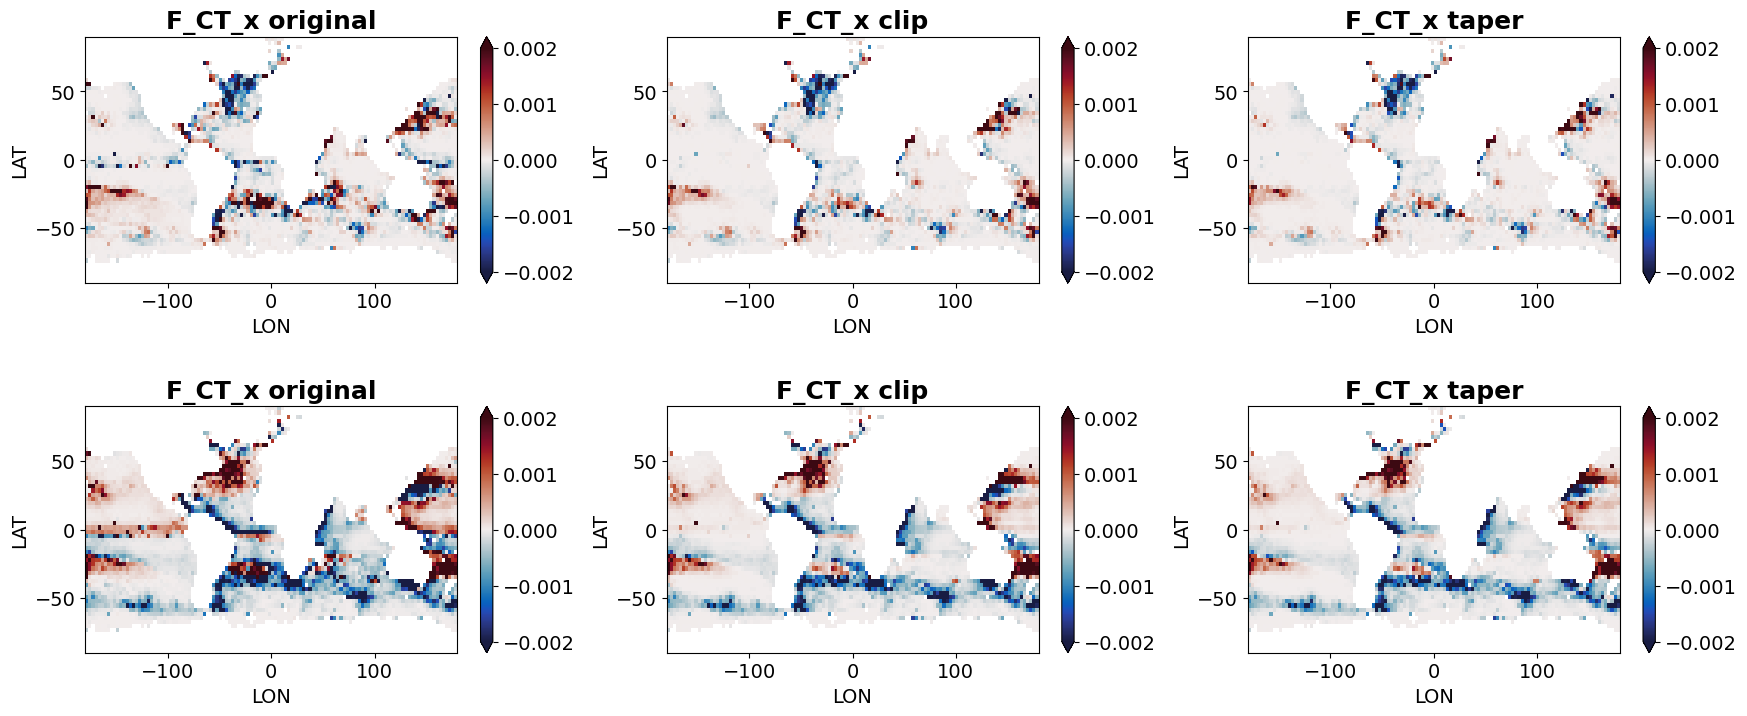

In [189]:
plt.figure(figsize=(21,8))
depth = 500


plt.subplot(231)
F_CT_x.sel(PRESSURE_mean=depth).plot(x='LON',y='LAT',cmap=cmo.balance, vmin=-0.002, vmax=0.002)
plt.title('F_CT_x original')

plt.subplot(232)
F_CT_x_clip.sel(PRESSURE_mean=depth).plot(x='LON',y='LAT',cmap=cmo.balance, vmin=-0.002, vmax=0.002)
plt.title('F_CT_x clip')

plt.subplot(233)
F_CT_x_tap.sel(PRESSURE_mean=depth).plot(x='LON',y='LAT',cmap=cmo.balance, vmin=-0.002, vmax=0.002)
plt.title('F_CT_x taper')

plt.subplot(234)
F_CT_y.sel(PRESSURE_mean=depth).plot(x='LON',y='LAT',cmap=cmo.balance, vmin=-0.002, vmax=0.002)
plt.title('F_CT_x original')

plt.subplot(235)
F_CT_y_clip.sel(PRESSURE_mean=depth).plot(x='LON',y='LAT',cmap=cmo.balance, vmin=-0.002, vmax=0.002)
plt.title('F_CT_x clip')

plt.subplot(236)
F_CT_y_tap.sel(PRESSURE_mean=depth).plot(x='LON',y='LAT',cmap=cmo.balance, vmin=-0.002, vmax=0.002)
plt.title('F_CT_x taper')

plt.subplots_adjust(wspace=0.25, hspace=0.5)

In [190]:
Cp = gsw.cp_t_exact(ds_pbar_grad.SA_m_bin, ds_pbar_grad.CT_m_bin, ds_pbar_grad.PRESSURE_mean)

In [193]:
F_heat_x = F_CT_x * (ds_pbar_grad.DENSITY +1000) * Cp
F_heat_y = F_CT_y * (ds_pbar_grad.DENSITY +1000) * Cp

F_heat_x_tap = F_CT_x_tap * (ds_pbar_grad.DENSITY +1000) * Cp
F_heat_y_tap = F_CT_y_tap * (ds_pbar_grad.DENSITY +1000) * Cp

F_heat_x_clip = F_CT_x_clip * (ds_pbar_grad.DENSITY +1000) * Cp
F_heat_y_clip = F_CT_y_clip * (ds_pbar_grad.DENSITY +1000) * Cp

In [198]:
basin = xr.open_dataset('/swot/SUM05/amf2288/basin.nc')
basin_on_grid = basin.sel(Z=0).interp(lat=ds_pbar_grad.LAT, lon=ds_pbar_grad.LON, method='nearest')
ds_pbar_grid['basin'] = (('LAT','LON'), basin_on_grid.basin.data)

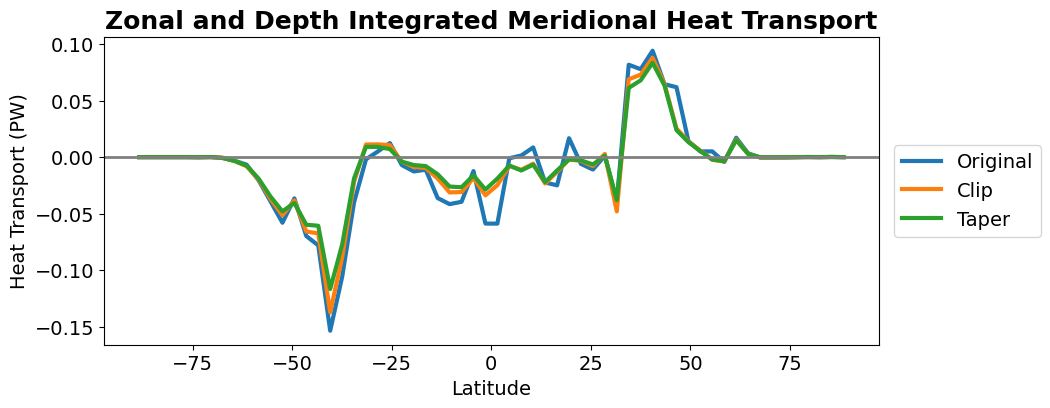

In [203]:
# ---------------------------------------------------------
# Compute zonal metric Δx
# ---------------------------------------------------------
R = 6371e3
dlon = np.deg2rad(float(ds_pbar_grid.LON[1] - ds_pbar_grid.LON[0]))
lat_rad = np.deg2rad(ds_pbar_grid.LAT)

dx = R * np.cos(lat_rad) * dlon
dx_da = xr.DataArray(dx, dims=['LAT'])
dx_3d = dx_da.broadcast_like(F_heat_y)

# ---------------------------------------------------------
# Add constant Δz (m)
# ---------------------------------------------------------
delta_z = 2.0   # choose your constant vertical thickness (meters)

# ---------------------------------------------------------
# Compute basin-specific meridional heat transport
# ---------------------------------------------------------
Fy_dx_dz_original = F_heat_y.sel(PRESSURE_mean=slice(200,2000)) * dx_3d * delta_z
Fy_dx_dz_clip = F_heat_y_clip.sel(PRESSURE_mean=slice(200,2000)) * dx_3d * delta_z
Fy_dx_dz_tap = F_heat_y_tap.sel(PRESSURE_mean=slice(200,2000)) * dx_3d * delta_z

#transport_atl    = Fy_dx_dz.where(ds_pbar_grid.basin==1).sum(dim=['PRESSURE_mean', 'LON'])
#transport_pac    = Fy_dx_dz.where(ds_pbar_grid.basin==2).sum(dim=['PRESSURE_mean', 'LON'])
#transport_ind    = Fy_dx_dz.where(ds_pbar_grid.basin==3).sum(dim=['PRESSURE_mean', 'LON'])
#transport_sou    = Fy_dx_dz.where(ds_pbar_grid.basin==10).sum(dim=['PRESSURE_mean', 'LON'])
#transport_art    = Fy_dx_dz.where(ds_pbar_grid.basin==11).sum(dim=['PRESSURE_mean', 'LON'])
transport_global = Fy_dx_dz_original.where(ds_pbar_grid.basin.isin([1, 2, 3, 10, 11])).sum(dim=['PRESSURE_mean', 'LON'])
transport_clip = Fy_dx_dz_clip.where(ds_pbar_grid.basin.isin([1, 2, 3, 10, 11])).sum(dim=['PRESSURE_mean', 'LON'])
transport_tap = Fy_dx_dz_tap.where(ds_pbar_grid.basin.isin([1, 2, 3, 10, 11])).sum(dim=['PRESSURE_mean', 'LON'])

# ---------------------------------------------------------
# Plot all curves
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(ds_pbar_grid.LAT, transport_global / 1e15, label='Original', linewidth=3)
ax.plot(ds_pbar_grid.LAT, transport_clip / 1e15, label='Clip', linewidth=3)
ax.plot(ds_pbar_grid.LAT, transport_tap / 1e15, label='Taper', linewidth=3)
##ax.plot(ds_pbar_grid.LAT, transport_atl    / 1e15, label='Atlantic', color='tab:blue')
#ax.plot(ds_pbar_grid.LAT, transport_pac    / 1e15, label='Pacific',  color='tab:orange')
#ax.plot(ds_pbar_grid.LAT, transport_ind    / 1e15, label='Indian',   color='tab:green')
#ax.plot(ds_pbar_grid.LAT, transport_sou    / 1e15, label='Southern', color='tab:red')
#ax.plot(ds_pbar_grid.LAT, transport_art    / 1e15, label='Arctic',   color='tab:purple')
ax.axhline(0, color='gray', linewidth=2)
ax.set_xlabel('Latitude')
ax.set_ylabel('Heat Transport (PW)')
ax.set_title('Zonal and Depth Integrated Meridional Heat Transport')

# Legend to the right, vertically centered
ax.legend(loc='center left',bbox_to_anchor=(1.02, 0.5),borderaxespad=0)
#plt.savefig('quals_paper/discussion/1_heat_transport.png', dpi=300, bbox_inches='tight')

## Sensitivity to Threshold

In [213]:
qs = np.arange(0,1,0.01)
Cs = []
for n,q in enumerate(qs):
    C = float((ds_pbar_grad.dCT_m_dx**2 + ds_pbar_grad.dCT_m_dy**2).quantile(q))
    Cs.append(C)
    print(f'done with q {n}')

done with q 0
done with q 1
done with q 2
done with q 3
done with q 4
done with q 5
done with q 6
done with q 7
done with q 8
done with q 9
done with q 10
done with q 11
done with q 12
done with q 13
done with q 14
done with q 15
done with q 16
done with q 17
done with q 18
done with q 19
done with q 20
done with q 21
done with q 22
done with q 23
done with q 24
done with q 25
done with q 26
done with q 27
done with q 28
done with q 29
done with q 30
done with q 31
done with q 32
done with q 33
done with q 34
done with q 35
done with q 36
done with q 37
done with q 38
done with q 39
done with q 40
done with q 41
done with q 42
done with q 43
done with q 44
done with q 45
done with q 46
done with q 47
done with q 48
done with q 49
done with q 50
done with q 51
done with q 52
done with q 53
done with q 54
done with q 55
done with q 56
done with q 57
done with q 58
done with q 59
done with q 60
done with q 61
done with q 62
done with q 63
done with q 64
done with q 65
done with q 66
done 

In [219]:
K_e_CT_clips = []
K_e_CT_taps  = []

for n,C in enumerate(Cs):
    lat_grad_clip = lat_grad.clip(min=C)
    K_e_CT_clip = K_rho_p * ds_pbar_grid.CT_e_var * (1/lat_grad_clip)
    K_e_CT_clips.append(K_e_CT_clip)

    lat_grad = (ds_pbar_grad.dCT_m_dx**2 + ds_pbar_grad.dCT_m_dy**2)
    lat_grad_tap = lat_grad / (lat_grad + C1)**2
    K_e_CT_tap = K_rho_p * ds_pbar_grid.CT_e_var * lat_grad_tap
    K_e_CT_taps.append(K_e_CT_tap)

    print(f'done with C {n}')

done with C 0
done with C 1
done with C 2
done with C 3
done with C 4
done with C 5
done with C 6
done with C 7
done with C 8
done with C 9
done with C 10
done with C 11
done with C 12
done with C 13
done with C 14
done with C 15
done with C 16
done with C 17
done with C 18
done with C 19
done with C 20
done with C 21
done with C 22
done with C 23
done with C 24
done with C 25
done with C 26
done with C 27
done with C 28
done with C 29
done with C 30
done with C 31
done with C 32
done with C 33
done with C 34
done with C 35
done with C 36
done with C 37
done with C 38
done with C 39
done with C 40
done with C 41
done with C 42
done with C 43
done with C 44
done with C 45
done with C 46
done with C 47
done with C 48
done with C 49
done with C 50
done with C 51
done with C 52
done with C 53
done with C 54
done with C 55
done with C 56
done with C 57
done with C 58
done with C 59
done with C 60
done with C 61
done with C 62
done with C 63
done with C 64
done with C 65
done with C 66
done 

In [228]:
K_e_CT_clips_avs = []
K_e_CT_taps_avs = []

for n in range(0,100,1):
    K_e_CT_clips_av = K_e_CT_clips[n].mean().data
    K_e_CT_taps_av = K_e_CT_taps[n].mean().data

    K_e_CT_clips_avs.append(K_e_CT_clips_av)
    K_e_CT_taps_avs.append(K_e_CT_taps_av)

    print(f'done with C{n}')

done with C0
done with C1
done with C2
done with C3
done with C4
done with C5
done with C6
done with C7
done with C8
done with C9
done with C10
done with C11
done with C12
done with C13
done with C14
done with C15
done with C16
done with C17
done with C18
done with C19
done with C20
done with C21
done with C22
done with C23
done with C24
done with C25
done with C26
done with C27
done with C28
done with C29
done with C30
done with C31
done with C32
done with C33
done with C34
done with C35
done with C36
done with C37
done with C38
done with C39
done with C40
done with C41
done with C42
done with C43
done with C44
done with C45
done with C46
done with C47
done with C48
done with C49
done with C50
done with C51
done with C52
done with C53
done with C54
done with C55
done with C56
done with C57
done with C58
done with C59
done with C60
done with C61
done with C62
done with C63
done with C64
done with C65
done with C66
done with C67
done with C68
done with C69
done with C70
done with C71
do

Text(0, 0.5, 'Global mean K_e')

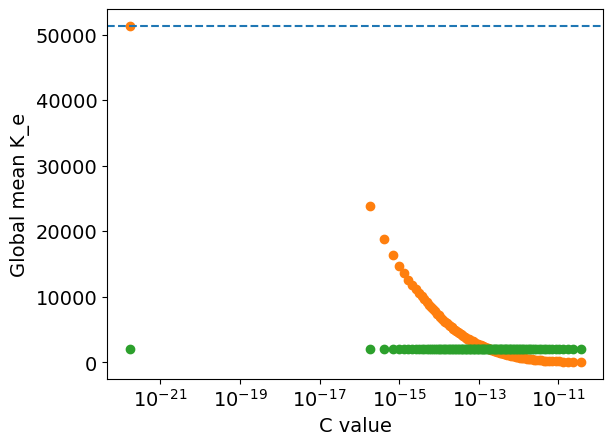

In [233]:
plt.scatter(Cs, K_e_CT_clips_avs, color='tab:orange', label='clip')
plt.scatter(Cs, K_e_CT_taps_avs, color='tab:green', label='taper')
plt.axhline(ds_pbar_grad.K_e_CT.mean().data, color='tab:blue', label='original', linestyle='--')
plt.xscale('log')
plt.xlabel('C value')
plt.ylabel('Global mean K_e')

In [ ]:
n = 0